### References:
1. Supervised Learning, https://en.wikipedia.org/wiki/Supervised_learning, accessed 2015/10/07

### About Supervised Learning
This week we will be doing a supervised learning task. Supervised learning models have a defined outcome and wish to use a set of additional variables to predict that outcome. Ultimately what we want is to have the algorithm guess the correct outcome based on data it has never seen before. 

Think about the ever-present example of customer churn we've been talking through in our lectures. In that case, we have historic data for which customers have renewed our service and which have cancelled. We also have a set of properties about those customers. We can run a supervised learning algorithm to guess whether current customers will cancel or renew.

When doing supervised learning problems, there are a few terms that get used quite a bit (as follows).

* **Model Traning** -- this is the process of creating the model. It generally means that we specify an outcome variable and a set of inputs and we run the model using some software package (R in our case).
* **Training data** -- this is the data used to train the model.
* **Test data** -- this is the data used to see if the training data will perform well on data it has never seen before. Generally speaking, the analyst will prepare one set of data and then split it into training data and test data.
* **Confusion matrix** -- this is the primary way we test to see if the algorithm has worked. Broadly speaking, we want to know how many times the algorithm guessed right and how many times it guessed wrong.
* **Overfitting** -- a model overfits the data when it has a very high accuracy on the training data and much worse accuracy on any other set of data. Overfitting is one of the most common issues seen in machine learning problems and is one of the most difficult things to avoid or fix. We won't talk about it much here, this being an introductory course on analytics and not on machine learning.

Models are generally broken into two categories. There are machine learning models and there are statistical models. Some types of models show up in both categories. Broadly speaking, machine learning models were created by computer scientists and focus a lot on prediction accuracy and hardly at all on interpretability (the ability to describe how the model functions). In contrast, statistical models were created by statisticians. Prediction accuracy is also a focus here, but statistical models tend to be more interpretable than machine learning models (and generally less accurate in some scenarios).

### About the data
Data for this exercise contains weather observations from a number of locations around Australia, obtained from the Australian Commonwealth Bureau of Meteorology. The data has been processed to provide a target variable RainTomorrow (whether there is rain on the following day - No/Yes) and a risk variable RISK_MM (how much rain). Various transformations are performed on the data.

### The Process
All supervised learning projects follow the same rough process as follows.

1. Problem definition
1. Data exploration
2. Data cleaning
3. Feature engineering
4. Training
5. Evaluation
6. Production

In our case, item #1 is done. We want to predict whether there will be rain tomorrow based on the weather stats for today. We will now walk through the rest of the steps here.

### Data Exploration and Data Cleaning
First, we need to load data set. In this case, we can download it easily from the course's database.

In [1]:
install.packages("fpc")
install.packages("RMySQL")
install.packages("summarytools")

# Downloading packages -------------------------------------------------------
- Downloading fpc from CRAN ...                 OK [839.7 Kb in 0.21s]
- Downloading mclust from CRAN ...              OK [3.9 Mb in 0.2s]
- Downloading flexmix from CRAN ...             OK [1.7 Mb in 0.2s]
- Downloading prabclus from CRAN ...            OK [470 Kb in 0.19s]
- Downloading diptest from CRAN ...             OK [170.2 Kb in 0.19s]
- Downloading robustbase from CRAN ...          OK [3 Mb in 0.2s]
- Downloading DEoptimR from CRAN ...            OK [72.8 Kb in 0.18s]
- Downloading kernlab from CRAN ...             OK [1.9 Mb in 0.24s]
Successfully downloaded 8 packages in 3.5 seconds.

The following package(s) will be installed:
- DEoptimR   [1.1-3]
- diptest    [0.77-1]
- flexmix    [2.3-19]
- fpc        [2.2-13]
- kernlab    [0.9-33]
- mclust     [6.1.1]
- prabclus   [2.3-4]
- robustbase [0.99-4-1]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu

In [ ]:
library(ggplot2)
library(fpc)
library(tidyverse)
library(rpart)
library(rpart.plot)

mm <- src_mysql(
  host='[updateme]',
  port=3306,
  user='admin',
  password='[updateme]',
  dbname='supervised_learning'
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“`src_mysql()` was deprecated in dplyr 1.0.0.
ℹ Please use `tbl()` directly with a database connection”


In [3]:
d_weather <- tbl(mm,'weather') %>% collect() %>% mutate_at(vars(MinTemp:Sunshine,WindGustSpeed,WindSpeed9am,Pressure9am:Temp3pm,RISK_MM),as.numeric)

Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `Sunshine = .Primitive("as.double")(Sunshine)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


Next we look at summaries of each of the variables. Note that most variables in the database are numeric but some are character data. For example, WindGustDir (or Wind Gust Direction) is a character variable telling us which direction the wind is blowing. Different models handle character data in different ways. We'll leave that discussion for another course (e.g. Data Mining).

In [4]:
summary(d_weather) # examine the summary statistics


     Date             Location            MinTemp          MaxTemp     
 Length:366         Length:366         Min.   :-5.300   Min.   : 7.60  
 Class :character   Class :character   1st Qu.: 2.300   1st Qu.:15.03  
 Mode  :character   Mode  :character   Median : 7.450   Median :19.65  
                                       Mean   : 7.266   Mean   :20.55  
                                       3rd Qu.:12.500   3rd Qu.:25.50  
                                       Max.   :20.900   Max.   :35.80  
                                                                       
    Rainfall       Evaporation        Sunshine      WindGustDir       
 Min.   : 0.000   Min.   : 0.200   Min.   : 0.000   Length:366        
 1st Qu.: 0.000   1st Qu.: 2.200   1st Qu.: 5.950   Class :character  
 Median : 0.000   Median : 4.200   Median : 8.600   Mode  :character  
 Mean   : 1.428   Mean   : 4.522   Mean   : 7.909                     
 3rd Qu.: 0.200   3rd Qu.: 6.400   3rd Qu.:10.500                    

In [5]:
library(summarytools)
descr(d_weather) %>% t()

Warning message:
“no DISPLAY variable so Tk is not available”
system might not have X11 capabilities; in case of errors when using dfSummary(), set st_options(use.x11 = FALSE)


Attaching package: ‘summarytools’


The following object is masked from ‘package:tibble’:

    view




,Mean,Std.Dev,Min,Q1,Median,Q3,Max,MAD,IQR,CV,Skewness,SE.Skewness,Kurtosis,N.Valid,Pct.Valid
Cloud3pm,4.024590,2.666268,0.0,1.0,4.00,7.0,8.0,4.44780,6.000,0.662494180,0.072301095,0.1275163,-1.63023412,366,100.00000
Cloud9am,3.890710,2.956131,0.0,1.0,3.50,7.0,8.0,3.70650,6.000,0.759791988,0.079775173,0.1275163,-1.71686547,366,100.00000
Evaporation,4.521858,2.669383,0.2,2.2,4.20,6.4,13.8,2.96520,4.200,0.590328705,0.658228261,0.1275163,-0.20876073,366,100.00000
Humidity3pm,44.519126,16.850947,13.0,32.0,43.00,55.0,96.0,16.30860,22.750,0.378510295,0.589864926,0.1275163,0.01155850,366,100.00000
Humidity9am,72.035519,13.137058,36.0,64.0,72.00,81.0,99.0,11.86080,17.000,0.182369174,-0.140299824,0.1275163,-0.20595527,366,100.00000
MaxTemp,20.550273,6.690516,7.6,15.0,19.65,25.5,35.8,7.41300,10.475,0.325568210,0.347510625,0.1275163,-0.76360944,366,100.00000
MinTemp,7.265574,6.025800,-5.3,2.3,7.45,12.5,20.9,7.63539,10.200,0.829363244,-0.003779725,0.1275163,-1.12569017,366,100.00000
Pressure3pm,1016.810383,6.469422,996.8,1012.8,1017.40,1021.5,1033.2,6.52344,8.675,0.006362467,-0.292831116,0.1275163,-0.03560288,366,100.00000
Pressure9am,1019.709016,6.686212,996.5,1015.3,1020.15,1024.5,1035.7,6.59757,9.125,0.006556980,-0.345738718,0.1275163,-0.07543813,366,100.00000
Rainfall,1.428415,4.225800,0.0,0.0,0.00,0.2,39.8,0.00000,0.200,2.958383031,4.552606775,0.1275163,26.23970072,366,100.00000


In [6]:
print(dfSummary(d_weather), method = 'render')


Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- tempfile(fileext = ".png"), width = 150 * graph.magnif, :
“unable to open connection to X11 display ''”
Warning message in png(png_loc <- 

Shiny tags cannot be represented in plain text (need html)


Remove attributes that aren't going to be helpful based on initial exploration (e.g. there is only a single location so remove this attribute)

In [7]:
d_weather_remove <- d_weather %>% select(-Location)
names(d_weather_remove) # note that Location has been removed

[1] "Date"          "MinTemp"       "MaxTemp"       "Rainfall"     
 [5] "Evaporation"   "Sunshine"      "WindGustDir"   "WindGustSpeed"
 [9] "WindDir9am"    "WindDir3pm"    "WindSpeed9am"  "WindSpeed3pm" 
[13] "Humidity9am"   "Humidity3pm"   "Pressure9am"   "Pressure3pm"  
[17] "Cloud9am"      "Cloud3pm"      "Temp9am"       "Temp3pm"      
[21] "RainToday"     "RISK_MM"       "RainTomorrow"

Convert data to the appropriate data type for each variable (e.g. Date is a character so convert it to a date). Note that we now see summary stats for the Date field.

In [8]:
class(d_weather$Date)
d_weather_date <- d_weather_remove %>% mutate(Date=as.Date(Date,format='%m/%d/%y'))
summary(d_weather_date)

[1] "character"

      Date        MinTemp          MaxTemp         Rainfall     
 Min.   :NA    Min.   :-5.300   Min.   : 7.60   Min.   : 0.000  
 1st Qu.:NA    1st Qu.: 2.300   1st Qu.:15.03   1st Qu.: 0.000  
 Median :NA    Median : 7.450   Median :19.65   Median : 0.000  
 Mean   :NaN   Mean   : 7.266   Mean   :20.55   Mean   : 1.428  
 3rd Qu.:NA    3rd Qu.:12.500   3rd Qu.:25.50   3rd Qu.: 0.200  
 Max.   :NA    Max.   :20.900   Max.   :35.80   Max.   :39.800  
 NA's   :366                                                    
  Evaporation        Sunshine      WindGustDir        WindGustSpeed  
 Min.   : 0.200   Min.   : 0.000   Length:366         Min.   :13.00  
 1st Qu.: 2.200   1st Qu.: 5.950   Class :character   1st Qu.:31.00  
 Median : 4.200   Median : 8.600   Mode  :character   Median :39.00  
 Mean   : 4.522   Mean   : 7.909                      Mean   :39.84  
 3rd Qu.: 6.400   3rd Qu.:10.500                      3rd Qu.:46.00  
 Max.   :13.800   Max.   :13.600                      Max.  

Next we might want to create a few data visualizations to help us understand the data better. Below we see a bar chart looking at the different values of the Wind Gust Direction and a density plot of the minimum temperature.

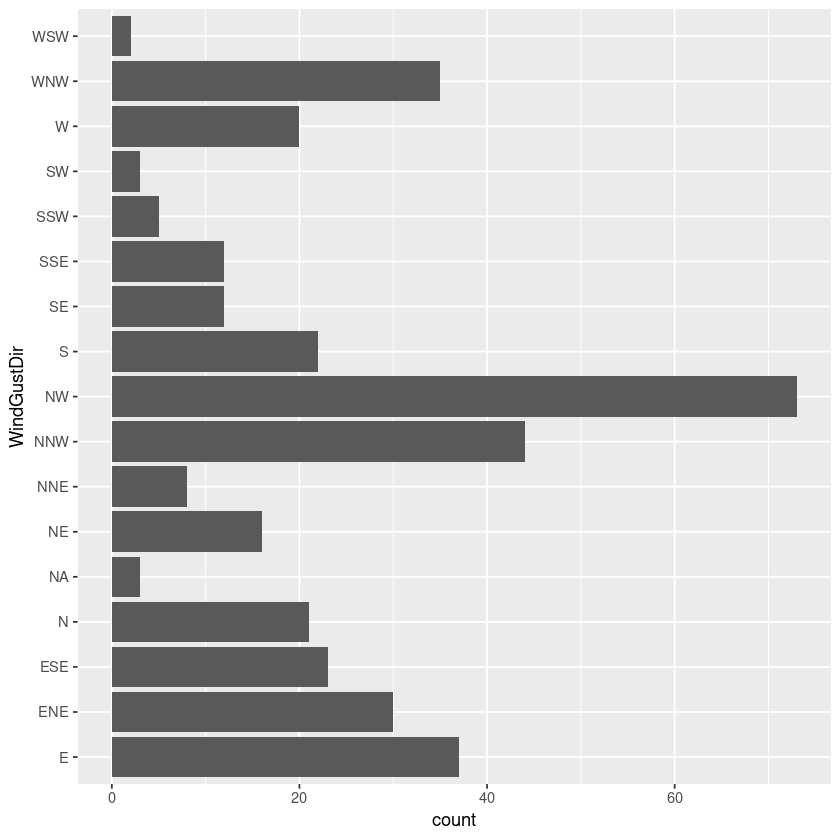

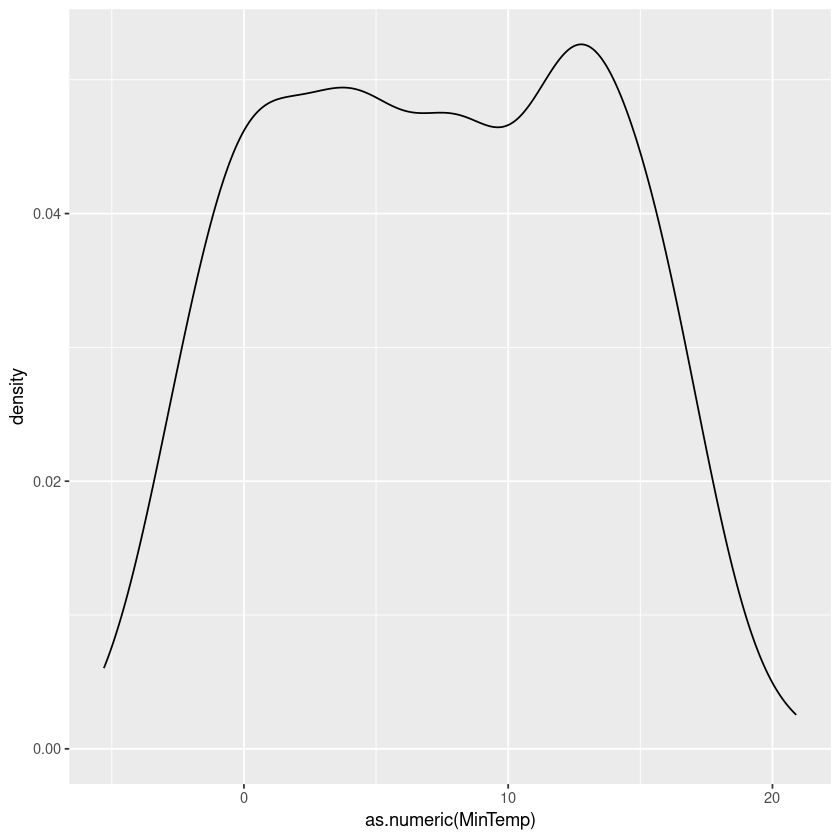

In [9]:
ggplot(d_weather, aes(x=WindGustDir)) + geom_bar() + coord_flip()
ggplot(d_weather, aes(x=as.numeric(MinTemp))) + geom_density()


### Feature Engineering
Feature engineering is a process where we decide which variables to include as inputs and how we might need to transform those variables. This could mean changing character data into numerical data in some way. It could also mean combining variables in a way that makes sense for the problem at hand. Feature engineering takes a good understanding of the problem and some creativity. 

Note that R handles character data naturally by creating what are called dummy codes (also known, for some reason, as one-hot encoding). This is where we create one variable for each of the values and then code them 1 for each value and 0 for all others.

### Model Training

The following code creates a decision tree model predicting the variable "RainTomorrow" with a handful of the other data points as predictor variables. These methods work by creating decision rules to decide what the forecast should be. These models generally guess where the decision rules should be placed and then check the accuracy of the model. In the next step, the model will guess different decision rules and keep the new rules if the model is more accurate. There are several variants of decision tree models, they all use this basic set up but vary in the details.

In [10]:
decision_tree_model <- rpart(RainTomorrow ~ MinTemp + MaxTemp + Rainfall + Evaporation + Sunshine + WindGustDir + WindGustSpeed,data=d_weather_date)


Often the best way to test if the model is functioning is to create what is called a Confusion Matrix. The following shows that we got 289 of the actual "No" rain days rignt (in that we also predicted a No). Likewise we got 41 "Yesses" right. This means that the model correctly classified `r scales::percent((289 + 41) / (289 + 25 + 11 + 41))` that is 90.16%.

In [11]:
d_weather_date$pred <- predict(decision_tree_model, type="class")
confusion_matrix <- d_weather_date %>% count(RainTomorrow,pred) %>% pivot_wider(names_from=RainTomorrow,values_from=n)
confusion_matrix %>% knitr::kable(col.names=c('Prediction','Actual: No','Actual: Yes'))



|Prediction | Actual: No| Actual: Yes|
|:----------|----------:|-----------:|
|No         |        289|          25|
|Yes        |         11|          41|

### Visualize the decision tree
Depending on the type of decision tree model used, you can actually plot the tree and inspect the details. The following is a plot of the tree we have created.

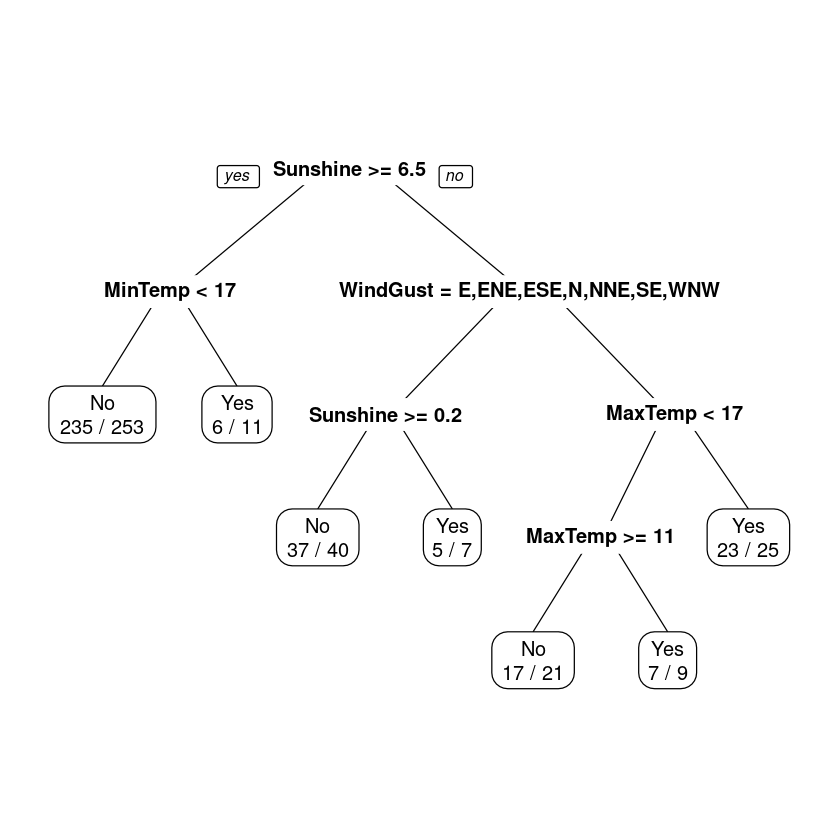

In [12]:
prp(decision_tree_model, extra = 2) 


In [14]:
# Create a new data frame with the specified conditions
new_data <- data.frame(
  MinTemp = as.numeric(NA), 
  MaxTemp = as.numeric(NA), 
  Rainfall = as.numeric(NA), 
  Evaporation = as.numeric(NA), 
  Sunshine = as.numeric(0.1), 
  WindGustDir = as.factor("ENE"), 
  WindGustSpeed = as.numeric(NA), 
  WindDir9am = as.factor(NA), 
  WindDir3pm = as.factor(NA), 
  WindSpeed9am = as.numeric(NA), 
  WindSpeed3pm = as.numeric(NA), 
  Humidity9am = as.numeric(NA), 
  Humidity3pm = as.numeric(NA), 
  Pressure9am = as.numeric(NA), 
  Pressure3pm = as.numeric(NA), 
  Cloud9am = as.numeric(NA), 
  Cloud3pm = as.numeric(NA), 
  Temp9am = as.numeric(NA), 
  Temp3pm = as.numeric(NA), 
  RainToday = as.factor(NA), 
  RISK_MM = as.numeric(NA)
)

# Predict whether it will rain tomorrow for the new data
new_data$RainTomorrow <- predict(decision_tree_model, new_data, type = "class")

new_data$RainTomorrow

[1] Yes
Levels: No Yes

# To-do
Log in to Datalab and click on SUBMIT-LAB6**** in the workspace for this course. This will be setup as an assignment for which you will create a personalized version of the file to work on. The environment is already setup to complete the exercises. 